# Convolutional Neural Networks for Eye Disease Detection

## Authors

Laura Cahill, Olivia Jones-Martin, Roberto Mercado, Zuriel Pagan

## Dataset

We use the [Retinal Fundus Multi-disease Image Dataset (RFMiD)](https://ieee-dataport.org/open-access/retinal-fundus-multi-disease-image-dataset-rfmid?check_logged_in=1) for this project, which is available on the IEEE DataPort website. It contains 3200 fundus color images captured by three different fundus cameras. The dataset is divided into a training set of 1920 images, validation set of 640 images, and testing set of 640 images. Ground truth labels are provided through CSV files, which account for 1 healthy class and 45 disease classes.

## Prerequisites

The following Python 3.12 modules are required to execute the cells of this notebook.

In [ ]:
from PIL import Image, ImageEnhance, ImageOps
from sklearn.metrics import confusion_matrix, classification_report
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import re
import seaborn as sns
import shutil
import torch

The following constants assume that the "All Classes" version of the dataset was downloaded from the IEEE DataPort website and placed into the same directory as this notebook.

In [3]:
DATA_PATH = 'A. RFMiD_All_Classes_Dataset'
IMAGE_PATH = f'{DATA_PATH}/1. Original Images'
GROUND_TRUTH_PATH = f'{DATA_PATH}/2. Groundtruths'
TRAINING_SET_PATH = f'{IMAGE_PATH}/a. Training Set'
VALIDATION_SET_PATH = f'{IMAGE_PATH}/b. Validation Set'
TESTING_SET_PATH = f'{IMAGE_PATH}/c. Testing Set'

It is highly recommended to run the models in this notebook on the GPU.

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
display(device)

device(type='cuda')

## Data Compression

Given the size of the images within the dataset, we had to compress the images before we uploading them to University of Massachusetts Lowell's GPU servers. To do this, we cropped the black borders surrounding the eye images and shrank the images down to 1028x1028 using the following commented code. This allowed our dataset to fit within our alloted disk space on the GPU server.

### Obtaining Image Paths

In [4]:
# DATASET_DIR = "./A. RFMiD_All_Classes_Dataset"
# image_paths = []

# def listImages(directory: str, image_path_array: list):
#     for subpath in os.listdir(directory):
#         subpath = os.path.join(directory, subpath)
#         print(subpath)
#         if re.search(r'\.(jpg|jpeg|png)$', subpath):
#             image_path_array.append(os.path.join(subpath))
#         if os.path.isdir(os.path.join(subpath)):
#             listImages(subpath, image_path_array)

# listImages(DATASET_DIR, image_paths)
# print(image_paths)

### Obtaining Image Sizes

In [5]:
# image_size_list = []
# image_size_dict = dict()

# for image_path in image_paths:
#     img = Image.open(image_path)
#     image_size_list.append((img.width, img.height))
#     if f"{img.width}-{img.height}" not in image_size_dict:
#         image_size_dict[f"{img.width}-{img.height}"] = []
#     image_size_dict[f"{img.width}-{img.height}"].append(image_path)

# image_size_list = list(set(image_size_list))
# for size in image_size_list:
#     print(size)
#     print(image_size_dict[f"{size[0]}-{size[1]}"])

### Compressing Images

In [6]:
# for path in image_paths:

#     # Open the image
#     img = Image.open(path)

#     width, height = img.size

#     # if it is already cropped, skip it
#     if width == 1028 and height == 1028:
#         img.close()
#         continue

#     # Convert to grayscale to find the light vs dark
#     bw = img.convert('L')

#     # Make comparison image a tenth of the size, in a bilinear way, to blur out any excess pixels
#     bw = bw.resize((width // 10, height // 10), resample=Image.BILINEAR)

#     # bring back to original size
#     bw = bw.resize((width, height), resample=Image.BILINEAR)

#     bw = ImageEnhance.Contrast(bw).enhance(2.0)

#     # getbbox finds the box around the eye
#     eye_box = bw.getbbox()

#     #if eye_box is real:

#     if eye_box:
#         img = img.crop(eye_box)

#     else:
#         print(f"Warning: Could not find eye box for image {path}. Skipping cropping.")

#     # Resize eye box to 1028x1028
#     img = img.resize((1028, 1028))

#     #Save it
#     img.save(path)
#     img.close()

# print("images have been cropped and resized to 1028x1028!")

## ResNet-18

ResNet-18 served as one of our baseline models for handling multilabel classification of eye diseases. Laura worked on setting up and training the ResNet-18 model.

### Utilities

The following utility classes were used to aid in the training and evaluation of the ResNet-18 model. Some adjustments were made to the prediction steps to account for the multi-label outputs.

In [ ]:
class FundusImageDataset(Dataset):
    '''
    Represents a partition of the RFMiD dataset.
    '''
    def __init__(self, metadata, image_directory, transform):
        '''
        Initializes a new instance of the FundusImageDataset that contains the
        specified data frame, loads images from the specified directory, and
        modifies them using the specified transform.

        :self: The instance to initialize.
        :metadata: The data frame containing ground truth labels.
        :image_directory: The directory containing images in the dataset.
        :transform: The transform used to modify images loaded from the dataset.
        '''
        self.metadata = metadata
        self.image_directory = image_directory
        self.transform = transform

    def __len__(self):
        '''
        Returns the size of the FundusImageDataset.

        :self: The instance to get the size of.
        :return: The size of the EyeImageDataset.
        '''
        return len(self.metadata)

    def __getitem__(self, index):
        '''
        Returns an image and vector of ground truth labels at the specified row
        index from the FundusImageDataset.

        :self: The instance to search.
        :index: The row index of the desired image and vector of ground truth
                labels.
        :return: A tuple containing an image and vector of ground truth labels
                 at index.
        '''
        row = self.metadata.iloc[index]
        filepath = f'{self.image_directory}/{row['ID']}.png'
        image = self.transform(Image.open(filepath))
        labels = torch.from_numpy(row[1:].to_numpy(float))
        return image, labels

class ModelEvaluator:
    '''
    Provides methods that evaluate data models according to a set of
    configurations.
    '''
    def __init__(self,
                 training_loader,
                 validation_loader,
                 testing_loader,
                 loss_criterion,
                 optimizer,
                 device):
        '''
        Initializes a new instance of the ModelEvaluator class that evaluates
        data models on data loaded from the specified data loaders into the
        specified device using specified loss criterion and optimizer.

        :param self: The instance to initialize.
        :param training_loader: The data loader containing the training set.
        :param validation_loader: The data loader containing the validation set.
        :param testing_loader: The data loader containing the testing set.
        :param loss_criterion: The loss function to use during training.
        :param optimizer: The optimizer to use during training.
        :param device: The device to load data into.
        '''
        self.training_loader = training_loader
        self.validation_loader = validation_loader
        self.testing_loader = testing_loader
        self.loss_criterion = loss_criterion
        self.optimizer = optimizer
        self.device = device

    def train(self, model, epoch_count):
        '''
        Trains and validates the specified data model through the
        ModelEvaluator.
        '''
        training_accuracies = np.zeros(epoch_count)
        training_losses = np.zeros(epoch_count)
        validation_accuracies = np.zeros(epoch_count)
        validation_losses = np.zeros(epoch_count)

        for epoch in range(epoch_count):
            # Begin training loop.
            model.train()
            total_loss = 0.0
            total_samples = 0.0
            total_correct = 0.0

            print(f"epoch {epoch}: starting")

            for inputs, labels in self.training_loader:
                inputs, labels = inputs.to(self.device), labels.to(self.device)
                self.optimizer.zero_grad()
                outputs = model(inputs)

                # Use 0.3 here as well for consistency across your project
                predictions = (torch.sigmoid(outputs) > 0.60).float()

                loss = self.loss_criterion(outputs, labels)
                loss.backward()
                self.optimizer.step()

                total_loss += loss.item()
                total_samples += labels.numel()
                total_correct += (predictions == labels).sum().item()

            training_accuracies[epoch] = total_correct / total_samples
            training_losses[epoch] = total_loss / len(self.training_loader)

            print("Training done. Onto validation.")

            # Begin validation loop.
            model.eval()
            val_labels = []
            val_preds = []
            val_total_loss = 0.0

            for inputs, labels in self.validation_loader:
                inputs, labels = inputs.to(self.device), labels.to(self.device)

                with torch.no_grad():
                    outputs = model(inputs)
                    loss = self.loss_criterion(outputs, labels)
                    val_total_loss += loss.item()
                    predictions = (torch.sigmoid(outputs) > 0.60).float()

                val_labels.append(labels.cpu().numpy())
                val_preds.append(predictions.cpu().numpy())

            # Stack everything into two big matrices
            val_labels = np.vstack(val_labels)
            val_preds = np.vstack(val_preds)

            # Calculate Macro F1
            from sklearn.metrics import f1_score, accuracy_score
            epoch_f1 = f1_score(val_labels, val_preds, average='macro', zero_division=0)

            # Update the metric arrays
            # Using (val_preds == val_labels).mean() gives bit-wise accuracy (Hamming)
            # accuracy_score gives subset accuracy (all 29 must match perfectly)
            validation_accuracies[epoch] = (val_preds == val_labels).mean()
            validation_losses[epoch] = val_total_loss / len(self.validation_loader)

            print(f"epoch {epoch}: F1-Score: {epoch_f1:.4f} | Bit-Accuracy: {validation_accuracies[epoch]:.4f}")

        return TrainingMetrics(training_accuracies,
                               training_losses,
                               validation_accuracies,
                               validation_losses)

    def test(self, model, label_names=None):
        model.eval()
        all_labels = []
        all_probs = [] # Changed from all_preds to all_probs

        with torch.no_grad():
            for inputs, labels in self.testing_loader:
                inputs, labels = inputs.to(self.device), labels.to(self.device)
                outputs = model(inputs)

                # Store RAW probabilities (0.0 to 1.0)
                probs = torch.sigmoid(outputs)

                all_labels.append(labels.cpu().numpy())
                all_probs.append(probs.cpu().numpy())

        # Combine all batches
        val_trues = np.vstack(all_labels)
        val_probs = np.vstack(all_probs)

        if label_names is None:
            label_names = [f"Class {i}" for i in range(val_trues.shape[1])]

        # --- Threshold Optimization ---
        best_thresholds = []
        for i in range(val_trues.shape[1]):
            best_f1 = -1
            best_thresh = 0.5

            y_prob = val_probs[:, i]
            y_true = val_trues[:, i]

            # Search for the best threshold for this specific disease
            for thresh in np.arange(0.05, 0.95, 0.01):
                y_pred = (y_prob >= thresh).astype(int)
                score = f1_score(y_true, y_pred, zero_division=0)
                if score > best_f1:
                    best_f1 = score
                    best_thresh = thresh
            best_thresholds.append(best_thresh)

        # Apply the optimized thresholds to get final predictions
        final_preds = np.zeros_like(val_probs)
        for i in range(val_trues.shape[1]):
            final_preds[:, i] = (val_probs[:, i] >= best_thresholds[i]).astype(int)

        # Generate the report
        print("Optimized Thresholds per class:")
        print(best_thresholds)

        report = classification_report(
            val_trues,
            final_preds,
            target_names=label_names,
            zero_division=0
        )

        print(report)
        return report, best_thresholds

class TrainingMetrics:
    '''
    Contains metrics that measure accuracy and loss across training epochs.
    '''
    def __init__(self,
                 training_accuracies,
                 training_losses,
                 validation_accuracies,
                 validation_losses):
        '''
        Initializes a new instance of the TrainingMetrics class that contains
        the specified lists of accuracies and losses obtained across training
        epochs.

        :param self: The instance to initialize.
        :param training_accuracies: The list of training accuracies.
        :param training_losses: The list of training losses.
        :param validation_accuracies: The list of validation accuracies.
        :param validation_losses: The list of validation losses.
        '''
        self.training_accuracies = training_accuracies
        self.training_losses = training_losses
        self.validation_accuracies = validation_accuracies
        self.validation_losses = validation_losses

    def show_accuracies(self):
        '''
        Shows a plot of the training and validation accuracies contained by the
        TrainingMetrics.

        :param self: The instance containing training and validation accuracies.
        '''
        epochs = range(1, len(self.training_accuracies) + 1)
        plt.figure(figsize=(10, 15))
        plt.subplot(2, 1, 2)
        plt.plot(epochs, self.training_accuracies, label='Training Accuracy')
        plt.plot(epochs, self.validation_accuracies, label='Validation Accuracy')
        plt.title('Training and Validation Accuracy')
        plt.xlabel('Epochs')
        plt.legend()
        plt.figure()
        plt.show()

    def show_losses(self):
        '''
        Shows a plot of the training and validation losses contained by the
        TrainingMetrics.

        :param self: The instance containing training and validation losses.
        '''
        epochs = range(1, len(self.training_losses) + 1)
        plt.figure(figsize=(10, 15))
        plt.subplot(2, 1, 2)
        plt.plot(epochs, self.training_losses, label='Training Loss')
        plt.plot(epochs, self.validation_losses, label='Validation Loss')
        plt.title('Training and Validation Loss')
        plt.xlabel('Epochs')
        plt.legend()
        plt.figure()
        plt.show()

### Dataset Setup

First, we need to set up the dataset for model evaluation. The dataset is presplit into training, validation, and testing sets already. Here, we load the metadata for each set.

In [ ]:
training_metadata = pd.read_csv(f'{GROUND_TRUTH_PATH}/a. RFMiD_Training_Labels.csv')
validation_metadata = pd.read_csv(f'{GROUND_TRUTH_PATH}/b. RFMiD_Validation_Labels.csv')
testing_metadata = pd.read_csv(f'{GROUND_TRUTH_PATH}/c. RFMiD_Testing_Labels.csv')

#for metadata in (training_metadata, validation_metadata, testing_metadata):
#    metadata.rename(columns={'Disease_Risk' : 'Healthy'}, inplace=True)
#    metadata['Healthy'] = metadata['Healthy'].apply(lambda value: int(not value))

Now, let's configure the dataset for use by ResNet-18. The FundusImageDataset class will handle the underlying logic for loading images and labels. We only need to supply the transform so that our images are properly sized for the model.

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)), # Higher resolution for small disease features
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

training_dataset = FundusImageDataset(training_metadata, TRAINING_SET_PATH, transform)
validation_dataset = FundusImageDataset(validation_metadata, VALIDATION_SET_PATH, transform)
testing_dataset = FundusImageDataset(testing_metadata, TESTING_SET_PATH, transform)

training_loader = DataLoader(training_dataset, batch_size=64, num_workers=6)
validation_loader = DataLoader(validation_dataset, batch_size=64, num_workers=6)
testing_loader = DataLoader(testing_dataset, batch_size=64, num_workers=7)

### Model Setup

Here, we set up ResNet-18 for use on our dataset.

In [ ]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT) #changed to resnet-18
model.aux_logits = False
model.fc = nn.Linear(model.fc.in_features, 29)
model = model.to(device)
display(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Then, we set up the class weights, loss function, and optimizer.

In [ ]:
# 1. Combine metadata
# (Since 'Othering' is already done in the CSVs, this just stacks them)
combined_metadata = pd.concat([training_metadata, validation_metadata, testing_metadata], ignore_index=True)

# 2. Extract only the label columns (dropping 'ID')
# This ensures we have exactly 29 columns
label_columns = combined_metadata.drop('ID', axis=1)
frequencies = label_columns.sum().to_numpy()

# 3. Calculate pos_weight for the 29 labels
# We use (Negative Samples / Positive Samples) for each class
# Adding 1e-6 prevents division by zero for extremely rare classes
total_samples = len(combined_metadata)
weights = np.sqrt((total_samples - frequencies) / (frequencies + 1e-6))
pos_weight = torch.FloatTensor(weights).to(device)

# 4. Initialize Model
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = torch.nn.Linear(model.fc.in_features, 29)
model.to(device)

# 5. Loss and Optimizer
# Passing pos_weight here is the key to fixing the 0.00 scores
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5) # Lower LR for stability

# Display to verify the weights aren't all the same
print("Weights for the 29 labels:")
display(pos_weight)

Weights for the 29 labels:


tensor([ 0.5141,  2.0158,  4.2350,  2.2624,  3.5935,  4.2617,  5.0883,  3.0865,
        11.0488,  6.2854, 10.8406,  7.1735,  2.4882,  8.3732, 17.8606, 11.2694,
         5.1794,  5.6862, 17.0267, 11.0488, 13.6834, 11.2694,  6.6386,  7.6328,
        11.5036,  9.9499, 13.6834, 17.8606,  6.6869], device='cuda:0')

### Model Evaluation

epoch1 done
epoch2 done
epoch3 done
epoch4 done
epoch5 done
epoch6 done
epoch7 done
epoch8 done
epoch9 done
epoch10 done
epoch11 done
epoch12 done
epoch13 done
epoch14 done
epoch15 done
epoch16 done
epoch17 done
epoch18 done
epoch19 done
epoch20 done


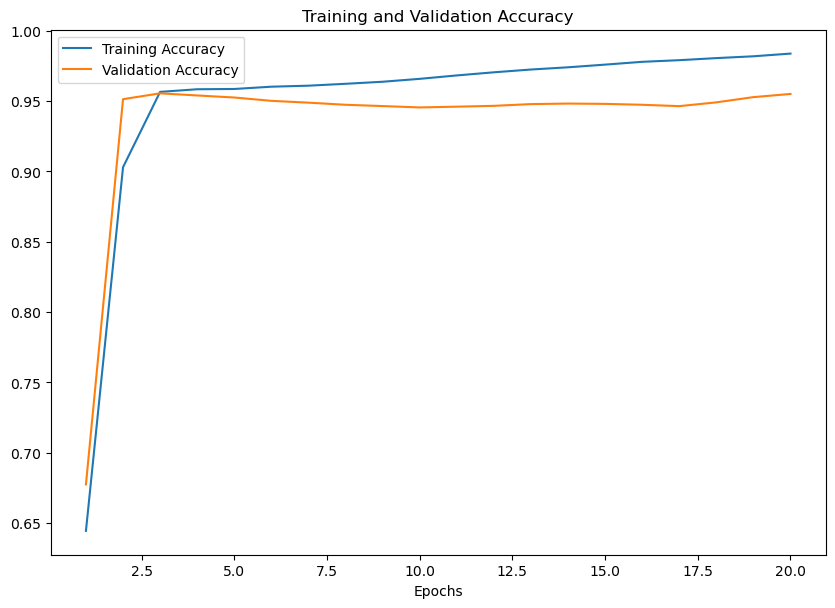

<Figure size 640x480 with 0 Axes>

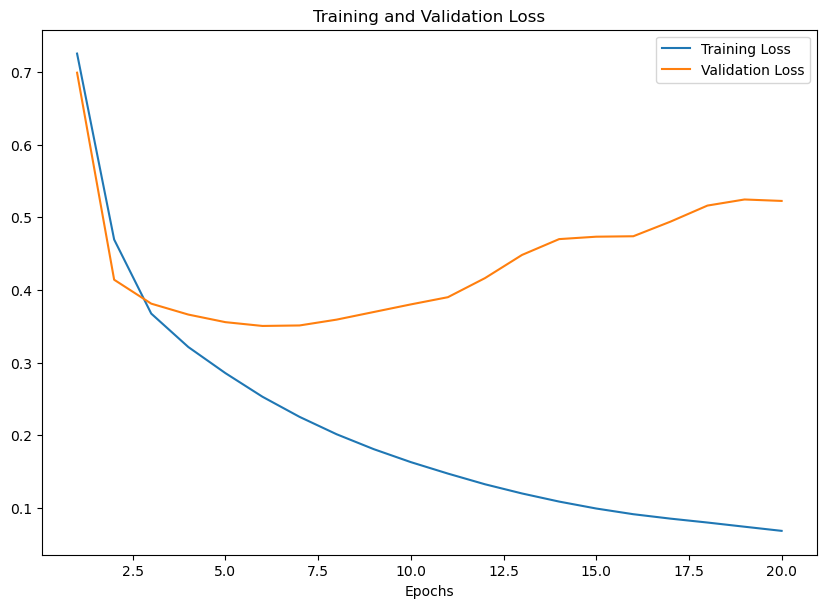

<Figure size 640x480 with 0 Axes>

In [ ]:
evaluator = ModelEvaluator(
    training_loader,
    validation_loader,
    testing_loader,
    criterion,
    optimizer,
    device
)


results = evaluator.train(model, 20)
results.show_accuracies()
results.show_losses()

The results show that the ResNet-18 model is getting high accuracies with a roughly 3 epochs. The validation accuracy did falter afterwards, but the training accuracy did increase steadily.

In [ ]:
# 1. Get the list of disease names (skipping the 'ID' column)
disease_names = testing_metadata.columns[1:].tolist()

# 2. Run the test method and pass those names in
evaluator.test(model)

array([[[126,   8],
        [ 73, 433]],

       [[500,  16],
        [ 57,  67]],

       [[606,   3],
        [ 23,   8]],

       [[472,  64],
        [  7,  97]],

       [[588,   6],
        [ 43,   3]],

       [[591,  17],
        [  3,  29]],

       [[586,  31],
        [  9,  14]],

       [[580,   7],
        [ 44,   9]],

       [[634,   1],
        [  5,   0]],

       [[625,   0],
        [ 14,   1]],

       [[633,   0],
        [  7,   0]],

       [[627,   0],
        [ 13,   0]],

       [[439, 110],
        [ 40,  51]],

       [[622,   9],
        [  3,   6]],

       [[638,   0],
        [  2,   0]],

       [[634,   1],
        [  2,   3]],

       [[610,   6],
        [ 22,   2]],

       [[623,   0],
        [  9,   8]],

       [[638,   0],
        [  2,   0]],

       [[636,   0],
        [  4,   0]],

       [[632,   4],
        [  4,   0]],

       [[635,   0],
        [  5,   0]],

       [[624,   2],
        [ 12,   2]],

       [[629,   0],
        [ 11, 

The confusion matrices show that the ResNet-18 model is able to identify cases where eye disease is present really well. However, it does have a lot of trouble classifying specific diseases, especially the rare ones (which the model has grown accustomed to make negative predictions on).